# **EXP05: Pipeline Architecture — Baseline vs Optimized**

### Objective: Determine what is the maximum improvement achievable by combining the best components from EXP01–04.


#### GPU Check

In [1]:
import torch

print("=" * 50)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA Available: True
GPU: Tesla T4


#### Clone Repository

In [2]:
!git clone https://github.com/ver1619/rag-bench.git
%cd rag-bench

Cloning into 'rag-bench'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 265 (delta 31), reused 23 (delta 12), pack-reused 214 (from 1)
Receiving objects: 100% (265/265), 64.30 MiB | 30.19 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/content/rag-bench


#### Dependencies

In [3]:
!pip install -q langchain-text-splitters nltk pymupdf sentence-transformers \
  torch qdrant-client rank-bm25 python-dotenv matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 37.2 MB/s eta 0:00:00


#### Qdrant Cloud Connection

In [4]:
from google.colab import userdata
from qdrant_client import QdrantClient

QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

cloud_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print("✅ Connected to Qdrant Cloud")

✅ Connected to Qdrant Cloud


#### 1. Define Pipeline Configurations

**Update with EXP01-04 best performers**


In [5]:
BASELINE_CONFIG = {
    "label": "Baseline",
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "chunker": "fixed",
    "retriever": "bm25",
    "reranker": "none",
    "collection": "exp05_baseline",
}

OPTIMIZED_CONFIG = {
    "label": "Optimized",
    # Replace with EXP02 winner:
    "embedding_model": "BAAI/bge-small-en-v1.5",
    # Replace with EXP03 winner:
    "chunker": "recursive",
    # Replace with EXP01 winner:
    "retriever": "dense",
    # Replace with EXP04 winner:
    "reranker": "cross",
    "collection": "exp05_optimized",
}

PIPELINES = [BASELINE_CONFIG, OPTIMIZED_CONFIG]

#### 2. Build + Index + Evaluate Both Pipelines

In [6]:
import json
import time
from pathlib import Path

from src.pipeline.factory import create_pipeline_builder
from src.ingestion.service import ingest_documents
from src.indexing.service import IndexingService
from src.vectordb.qdrant import QdrantVectorStore

from src.retrieval.factory import (
    create_dense_retriever,
    create_bm25_retriever,
    create_hybrid_retriever,
)
from src.retrieval.pipeline import RetrievalPipeline

from src.rerankers.factory import (
    create_cross_encoder_reranker,
    create_bge_reranker,
    create_mxbai_reranker,
)

from src.evaluation.dataset import EvaluationDataset
from src.evaluation.latency import Latency
from src.evaluation.runner import EvaluationRunner
from src.evaluation.metrics import (
    RecallAtK,
    PrecisionAtK,
    MeanReciprocalRank,
    NormalizedDiscountedCumulativeGain,
)

# Patch vector store for Qdrant Cloud
vector_store = QdrantVectorStore.__new__(QdrantVectorStore)
vector_store.host = QDRANT_URL
vector_store.port = 6333
vector_store.client = cloud_client

metrics = [
    RecallAtK(),
    PrecisionAtK(),
    MeanReciprocalRank(),
    NormalizedDiscountedCumulativeGain(),
]

dataset = EvaluationDataset("data/queries/queries.json")

reranker_factory = {
    "none": lambda: None,
    "cross": create_cross_encoder_reranker,
    "bge": create_bge_reranker,
    "mxbai": create_mxbai_reranker,
}

results = {}

for config in PIPELINES:

    label = config["label"]
    collection = config["collection"]

    print(f"\n{'='*60}")
    print(f"Pipeline : {label}")
    print(f"Embedding: {config['embedding_model']}")
    print(f"Chunker  : {config['chunker']}")
    print(f"Retriever: {config['retriever']}")
    print(f"Reranker : {config['reranker']}")
    print(f"{'='*60}")

    # Write config
    config_path = Path("data/metadata/config.json")
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with config_path.open("w") as f:
        json.dump({
            "embedding_model": config["embedding_model"],
            "chunker": config["chunker"],
        }, f, indent=4)

    # Build pipeline
    builder = create_pipeline_builder(
        model_name=config["embedding_model"],
        chunker=config["chunker"],
    )
    pipeline = builder.build()

    print(f"Chunks: {len(pipeline.chunks)}")

    # Index
    indexer = IndexingService(
        vector_store=vector_store,
        collection_name=collection,
    )

    indexer.index(
        embeddings=pipeline.embeddings,
        overwrite=True,
    )

    # Create retriever
    embedder = builder.embedder
    chunks = pipeline.chunks

    retriever_map = {
        "dense": lambda: create_dense_retriever(
            vector_store=vector_store,
            embedder=embedder,
            collection_name=collection,
        ),
        "bm25": lambda: create_bm25_retriever(chunks=chunks),
        "hybrid": lambda: create_hybrid_retriever(
            vector_store=vector_store,
            embedder=embedder,
            collection_name=collection,
            chunks=chunks,
        ),
    }

    retriever = retriever_map[config["retriever"]]()
    reranker = reranker_factory[config["reranker"]]()

    retrieval_pipeline = RetrievalPipeline(
        retriever=retriever,
        reranker=reranker,
    )

    # Evaluate
    runner = EvaluationRunner(
        retrieval_pipeline=retrieval_pipeline,
        dataset=dataset,
        metrics=metrics,
        latency=Latency(),
    )

    start = time.perf_counter()
    benchmark = runner.run(top_k=5)
    elapsed = time.perf_counter() - start

    s = benchmark.summary

    results[label] = {
        "Recall@5": s.recall,
        "Precision@5": s.precision,
        "MRR": s.mrr,
        "nDCG@5": s.ndcg,
        "Latency (ms)": s.latency_ms,
        "Benchmark Time (s)": round(elapsed, 2),
    }

    print(f"\nRecall@5    : {s.recall:.4f}")
    print(f"Precision@5 : {s.precision:.4f}")
    print(f"MRR         : {s.mrr:.4f}")
    print(f"nDCG@5      : {s.ndcg:.4f}")
    print(f"Latency     : {s.latency_ms:.2f}ms")

    cloud_client.delete_collection(collection)
    print(f"✅ Collection '{collection}' deleted")

print("\n✅ Pipeline showdown complete")


Pipeline : Baseline
Embedding: sentence-transformers/all-MiniLM-L6-v2
Chunker  : fixed
Retriever: bm25
Reranker : none


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Evaluating [263/263]

Recall@5    : 0.3682
Precision@5 : 0.3273
MRR         : 0.3682
nDCG@5      : 0.3645
Latency     : 209.56ms
✅ Collection 'exp05_optimized' deleted

✅ Pipeline showdown complete


#### 3. Results

In [7]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "Pipeline"
print(df.to_string(float_format="%.4f"))

           Recall@5  Precision@5    MRR  nDCG@5  Latency (ms)  Benchmark Time (s)
Pipeline                                                                         
Baseline     0.3650       0.2897 0.3625  0.3642      173.8763             46.0100
Optimized    0.3682       0.3273 0.3682  0.3645      209.5596             55.3800


#### 4. Before / After

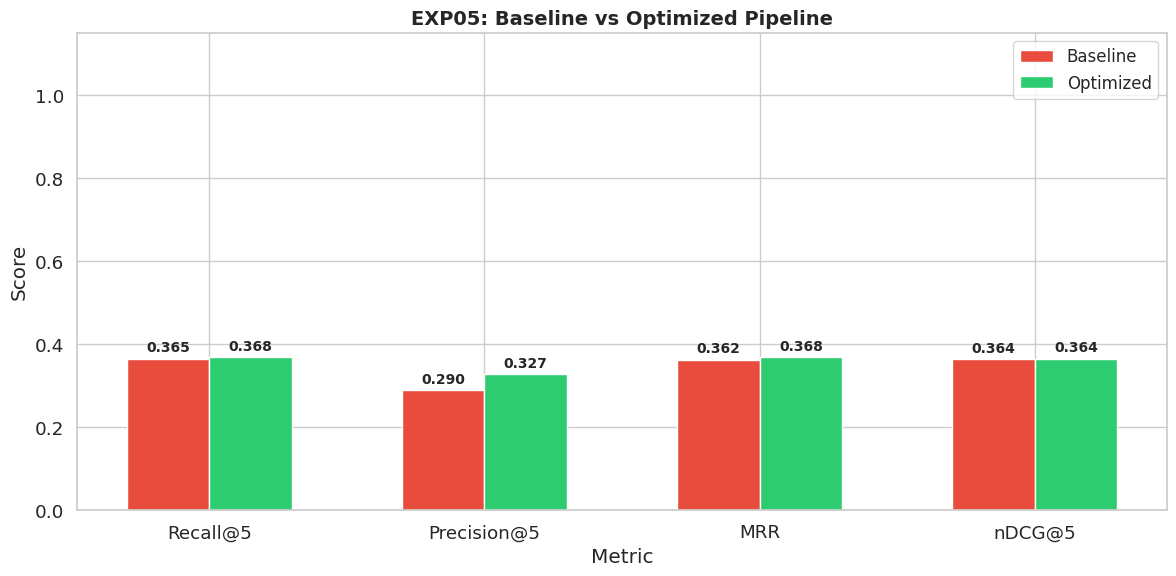

✅ Chart saved: exp05_showdown.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.2)

metric_cols = ["Recall@5", "Precision@5", "MRR", "nDCG@5"]
pipelines = list(results.keys())

x = np.arange(len(metric_cols))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#e74c3c", "#2ecc71"]

for i, pipeline_name in enumerate(pipelines):
    values = [results[pipeline_name][m] for m in metric_cols]
    bars = ax.bar(x + i * width, values, width, label=pipeline_name, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("EXP05: Baseline vs Optimized Pipeline", fontweight="bold", fontsize=14)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("exp05_showdown.png", dpi=150)
plt.show()

print("✅ Chart saved: exp05_showdown.png")

#### 5. Radar

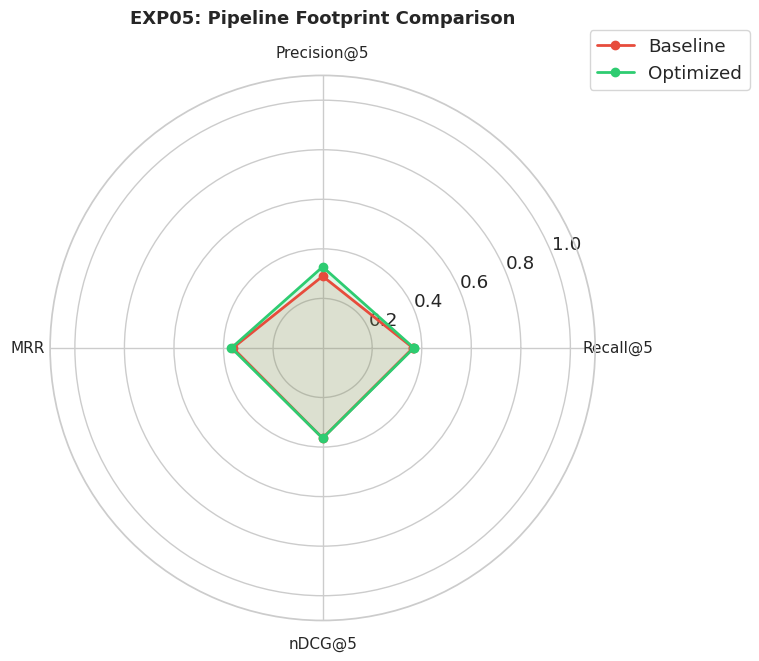

✅ Chart saved: exp05_radar.png


In [9]:
metric_cols_radar = ["Recall@5", "Precision@5", "MRR", "nDCG@5"]
labels = metric_cols_radar

# Normalize latency (invert: lower is better)
max_latency = max(results[p]["Latency (ms)"] for p in pipelines)

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = ["#e74c3c", "#2ecc71"]

for i, pipeline_name in enumerate(pipelines):
    values = [results[pipeline_name][m] for m in metric_cols_radar]
    values += values[:1]  # Close the polygon

    ax.plot(angles, values, "o-", linewidth=2, label=pipeline_name, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("EXP05: Pipeline Footprint Comparison", fontweight="bold", fontsize=13, y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("exp05_radar.png", dpi=150)
plt.show()

print("✅ Chart saved: exp05_radar.png")

#### 6. Improvement

In [10]:
baseline = results["Baseline"]
optimized = results["Optimized"]

print("\n" + "=" * 50)
print("IMPROVEMENT SUMMARY")
print("=" * 50)

for metric in metric_cols:
    b = baseline[metric]
    o = optimized[metric]
    if b > 0:
        improvement = ((o - b) / b) * 100
        arrow = "↑" if improvement > 0 else "↓"
        print(f"{metric:15s}: {b:.4f} → {o:.4f}  ({arrow} {abs(improvement):.1f}%)")
    else:
        print(f"{metric:15s}: {b:.4f} → {o:.4f}")

print("=" * 50)


IMPROVEMENT SUMMARY
Recall@5       : 0.3650 → 0.3682  (↑ 0.9%)
Precision@5    : 0.2897 → 0.3273  (↑ 13.0%)
MRR            : 0.3625 → 0.3682  (↑ 1.6%)
nDCG@5         : 0.3642 → 0.3645  (↑ 0.1%)
